[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mihdicaballero/mento/blob/main/docs/source/examples/viga_rectangular_diseno_CIRSOC_201-25.ipynb)

In [1]:
# Google Colab no trae mento instalado, así que lo instalamos sólo cuando el
# notebook corre allí. La guarda evita que la documentación llame a pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# Diseño de viga rectangular — CIRSOC 201-25

Este ejemplo dimensiona la armadura de una viga rectangular de hormigón armado según el
**CIRSOC 201-2025**, el reglamento argentino. mento la implementa en `Concrete_CIRSOC_201_25`,
que comparte las expresiones del ACI 318-19 y trabaja siempre en unidades métricas.

*Diseñar* significa que mento elige la armadura: le damos la sección, los materiales y los
estados de carga, y devuelve las barras longitudinales y los estribos necesarios. Si en
cambio ya tenés la armadura y querés verificarla, mirá el ejemplo de
[verificación](viga_rectangular_verificacion_CIRSOC_201-25.ipynb).


#### Idioma español para salida de anexos

In [14]:
import mento

mento.set_language("es")

**Materiales y geometría de la sección**

In [3]:
from mento import Concrete_CIRSOC_201_25, SteelBar, RectangularBeam, cm, kN, MPa, kNm
from mento import Forces, Node

# Materiales
hormigon = Concrete_CIRSOC_201_25(name="H-25", f_c=25 * MPa)
acero = SteelBar(name="ADN 420", f_y=420 * MPa)

# Geometría de la viga: ancho, altura y recubrimiento
viga = RectangularBeam(
    label="V101",
    concrete=hormigon,
    steel_bar=acero,
    width=20 * cm,
    height=50 * cm,
    c_c=2.5 * cm,
)
viga.data

Beam V101, $b$=20.00 cm, $h$=50.00 cm, $c_{c}$=2.50 cm,                             Concrete H-25, Rebar ADN 420.

**Estados de carga**

Cada `Forces` es una combinación mayorada. `M_y` es el momento flector y `V_z` el esfuerzo de
corte; el signo del momento distingue la cara traccionada (positivo tracciona abajo).

In [4]:
f1 = Forces(label="1.2D+1.6L", M_y=80 * kNm, V_z=70 * kN)
f2 = Forces(label="1.2D+1.6L+W", M_y=-35 * kNm, V_z=45 * kN)
print(f1)
print(f2)

Force ID: 1, Label: 1.2D+1.6L, N_x: 0.00 kN, V_z: 70.00 kN, M_y: 80.00 kN·m
Force ID: 2, Label: 1.2D+1.6L+W, N_x: 0.00 kN, V_z: 45.00 kN, M_y: -35.00 kN·m


**Nodo: sección más estados de carga**

El `Node` une la sección con la lista de combinaciones. Es sobre el nodo donde se corre el
diseño, y mento dimensiona para la combinación más exigente de la lista.

In [5]:
nodo = Node(section=viga, forces=[f1, f2])
nodo

Node ID: 1 - Section label: V101
Forces Applied:
  - Force ID: 1, Label: 1.2D+1.6L, N_x: 0.00 kN, V_z: 70.00 kN, M_y: 80.00 kN·m
  - Force ID: 2, Label: 1.2D+1.6L+W, N_x: 0.00 kN, V_z: 45.00 kN, M_y: -35.00 kN·m

**Diseño a flexión y corte**

In [6]:
# Dimensiona armadura longitudinal y estribos
nodo.design()

# Resumen de resultados
nodo.results

Beam V101, $b$=20.00 cm, $h$=50.00 cm, $c_{c}$=2.50 cm,                             Concrete H-25, Rebar ADN 420.

Top longitudinal rebar: 2Ø12+1Ø10, $A_{s,top}$ = 3.05 cm², $M_u$ = -35 kNm, $\phi M_n$ = 51.63 kNm → $\color{#439b00}{\text{DCR}=0.68}$ 

Bottom longitudinal rebar: 2Ø16+1Ø12, $A_{s,bot}$ = 5.15 cm², $M_u$ = 80 kNm, $\phi M_n$ = 84.91 kNm → $\color{#439b00}{\text{DCR}=0.94}$ 

Shear reinforcing 1eØ6/22 cm, $A_v$=2.57 cm²/m, $V_u$=70 kN, $\phi V_n$=96.19 kN → $\color{#439b00}{\text{DCR}=0.73}$ 

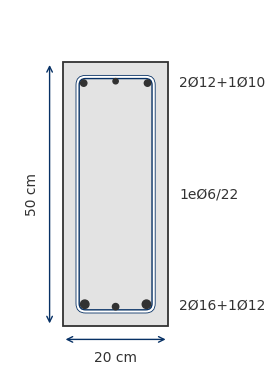

In [7]:
# Sección con la armadura adoptada
viga.plot()

**Resultados en tablas**

`check_flexure()` y `check_shear()` devuelven un `DataFrame` de pandas con una fila por
combinación, cómodo para revisar varias vigas o exportar a Excel.

In [8]:
nodo.check_flexure()

,Label,Comb.,Position,"As,min","As,req top","As,req bot",As,Mu,ØMn,Mu≤ØMn,DCR
0,,,,cm²,cm²,cm²,cm²,kNm,kNm,,
1,V101,1.2D+1.6L,Bottom,3.08,0.0,4.84,5.15,80,84.91,True,0.942
2,V101,1.2D+1.6L+W,Top,3.09,2.72,0.0,3.05,-35,51.63,True,0.678


In [9]:
nodo.check_shear()

,Label,Comb.,"Av,min","Av,req",Av,Vu,Nu,ØVc,ØVs,ØVn,ØVmax,Vu≤ØVmax,Vu≤ØVn,DCR
0,,,cm²/m,cm²/m,cm²/m,kN,kN,kN,kN,kN,kN,,,
1,V101,1.2D+1.6L,1.67,1.67,2.57,70,0,58.83,37.36,96.19,287.25,True,True,0.728
2,V101,1.2D+1.6L+W,1.67,1.67,2.57,45,0,58.83,37.36,96.19,287.25,True,True,0.468


**Leer la armadura adoptada desde el código**

Cuando lo que necesitás no es la tabla sino los valores — por ejemplo para armar una planilla
de despiece o alimentar otro cálculo — usá `viga.flexure_design` y `viga.shear_design`. Son
objetos de datos, con unidades, que devuelven exactamente lo que el diseño adoptó.

Cada cantidad es un `Quantity` de pint, así que se convierte a la unidad que prefieras con
`.to()`. Las áreas requeridas y los DCR son la envolvente de todos los estados de carga: el
DCR de una cara es el de la combinación que la gobierna.

In [10]:
flexion = viga.flexure_design
corte = viga.shear_design

print("Armadura inferior:", flexion.bottom)
print(f"  As adoptada  = {flexion.bottom.A_s.to('cm**2'):.2f~P}")
print(f"  As requerida = {flexion.bottom.A_s_req.to('cm**2'):.2f~P}")
print(f"  As mínima    = {flexion.bottom.A_s_min.to('cm**2'):.2f~P}")
print("Armadura superior:", flexion.top)
print("Estribos:", corte, f"({corte.n_legs} ramas)")
print(f"  Av adoptada  = {corte.A_v.to('cm**2/m'):.2f~P}")
print(f"  Av requerida = {corte.A_v_req.to('cm**2/m'):.2f~P}")
print(f"DCR flexión = {flexion.DCR:.2f} | DCR corte = {corte.DCR:.2f}")

Armadura inferior: 2Ø16 mm + 1Ø12 mm
  As adoptada  = 5.15 cm²
  As requerida = 4.84 cm²
  As mínima    = 3.08 cm²
Armadura superior: 2Ø12 mm + 1Ø10 mm
Estribos: 1eØ6 mm/22 cm (2 ramas)
  Av adoptada  = 2.57 cm²/m
  Av requerida = 1.67 cm²/m
DCR flexión = 0.94 | DCR corte = 0.73


**Memoria de cálculo detallada**

Para la combinación que gobierna, mento muestra el cálculo completo: propiedades de los
materiales, geometría, cada verificación del reglamento y la relación demanda-capacidad.

In [11]:
nodo.flexure_results_detailed()

===== RESULTADOS DETALLADOS DE FLEXIÓN DE VIGA =====
Materiales                      Variable     Valor  Unidad
-----------------------------  ----------  -------  --------
Identificación de la sección                  V101
Resistencia del hormigón           fc           25  MPa
Tensión de fluencia del acero      fy          420  MPa 

Geometría                         Variable     Valor  Unidad
-------------------------------  ----------  -------  --------
Altura de la sección                 h            50  cm
Ancho de la sección                  b            20  cm
Recubrimiento geométrico             cc          2.5  cm
Recubrimiento mecánico superior    cm,top       3.67  cm
Recubrimiento mecánico inferior    cm,bot       3.86  cm 

Solicitaciones            Variable     Valor  Unidad
-----------------------  ----------  -------  --------
Momento máximo superior    Mu,top        -35  kNm
Momento máximo inferior    Mu,bot         80  kNm 

Verificación                         Unid

In [12]:
nodo.shear_results_detailed()

===== RESULTADOS DETALLADOS DE CORTE DE VIGA =====
Materiales                            Variable     Valor  Unidad
-----------------------------------  ----------  -------  --------
Identificación de la sección                        V101
Resistencia del hormigón                 fc           25  MPa
Tensión de fluencia del acero            fy          420  MPa
Densidad del hormigón                    wc       2500.0  kg/m³
Hormigón de densidad normal              λ             1
Coeficiente de seguridad para corte      Øv         0.75 

Geometría                           Variable     Valor  Unidad
---------------------------------  ----------  -------  --------
Altura de la sección                   h            50  cm
Ancho de la sección                    b            20  cm
Recubrimiento geométrico               cc          2.5  cm
Armadura longitudinal traccionada      As         3.05  cm² 

Solicitaciones                 Variable     Valor  Unidad
----------------------------  -

**Exportar a Word y a Excel**

Las mismas memorias se exportan a un documento de Word, y las tablas a Excel. Los archivos se
escriben en el directorio de trabajo.

In [13]:
nodo.flexure_results_detailed_doc()
nodo.shear_results_detailed_doc()

nodo.check_flexure().to_excel("CIRSOC 201-25 resultados flexion.xlsx")
nodo.check_shear().to_excel("CIRSOC 201-25 resultados corte.xlsx")